In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler,RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

In [2]:
df=pd.read_excel('Student_Performance.xlsx')

In [3]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91
1,4,82,No,4,2,65
2,8,51,Yes,7,2,45
3,5,52,Yes,5,2,36
4,7,75,No,8,5,66


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Hours Studied                     10000 non-null  int64 
 1   Previous Scores                   10000 non-null  int64 
 2   Extracurricular Activities        10000 non-null  object
 3   Sleep Hours                       10000 non-null  int64 
 4   Sample Question Papers Practiced  10000 non-null  int64 
 5   Performance Index                 10000 non-null  int64 
dtypes: int64(5), object(1)
memory usage: 468.9+ KB


In [5]:
num_df=df.select_dtypes(include='number')
num_df

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,9,1,91
1,4,82,4,2,65
2,8,51,7,2,45
3,5,52,5,2,36
4,7,75,8,5,66
...,...,...,...,...,...
9995,1,49,4,2,23
9996,7,64,8,5,58
9997,6,83,8,5,74
9998,9,97,7,0,95


In [6]:
x=num_df.drop('Performance Index',axis=1) #num_df[['H',]]
y=num_df['Performance Index']

In [7]:
x

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced
0,7,99,9,1
1,4,82,4,2
2,8,51,7,2
3,5,52,5,2
4,7,75,8,5
...,...,...,...,...
9995,1,49,4,2
9996,7,64,8,5
9997,6,83,8,5
9998,9,97,7,0


In [8]:
y

0       91
1       65
2       45
3       36
4       66
        ..
9995    23
9996    58
9997    74
9998    95
9999    64
Name: Performance Index, Length: 10000, dtype: int64

In [9]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

In [10]:
xtrain

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced
9254,5,49,7,5
1561,2,48,7,6
1670,2,81,7,2
6087,2,46,6,1
6669,8,47,9,0
...,...,...,...,...
5734,8,50,6,6
5191,4,68,9,3
5390,9,48,7,6
860,1,47,9,0


In [11]:
ytrain

9254    36
1561    25
1670    59
6087    22
6669    40
        ..
5734    48
5191    51
5390    44
860     20
7270    24
Name: Performance Index, Length: 8000, dtype: int64

In [12]:
model=LinearRegression()

In [13]:
model.fit(xtrain,ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


column transformer

In [14]:
num_col=xtrain.select_dtypes(include='number').columns
obj_col=xtrain.select_dtypes(exclude='number').columns


In [15]:
preprocessing=ColumnTransformer(
    transformers=[
        ('scaler',StandardScaler(),num_col),
        ('one_hot encoder',OneHotEncoder(sparse_output='False',handle_unknown='ignore'),obj_col)
    ]
)


In [16]:
decisiontree_pipeline=Pipeline(
    steps=[
('preprocessing',preprocessing),
('model',DecisionTreeRegressor())
    ]
)

In [17]:
decisiontree_pipeline.fit(xtrain,ytrain)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaler', ...), ('one_hot encoder', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [18]:
decisiontree_pipeline.score(xtrain,ytrain)

0.9986735929687195

In [19]:
model.intercept_

np.float64(-33.60206732749263)

In [20]:
model.coef_

array([2.85289351, 1.01703572, 0.47331832, 0.19172629])

In [21]:
xtest

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced
6252,5,69,8,2
4684,2,46,4,8
1731,7,56,7,5
4742,6,42,8,5
4521,7,53,4,6
...,...,...,...,...
6412,2,70,7,3
8285,4,79,9,3
7853,2,40,7,2
1095,3,83,7,5


In [22]:
ytest

6252    51
4684    20
1731    46
4742    28
4521    41
        ..
6412    45
8285    66
7853    16
1095    65
6929    47
Name: Performance Index, Length: 2000, dtype: int64

In [23]:
predicted_values=model.predict(xtest)

In [24]:
# test=xtest

In [25]:
# test

In [26]:
# test['Actual_output']=ytest

In [27]:
# test

In [28]:
# test['predicted_output']=predicted_values

In [29]:
# test

In [30]:
num_df.corr()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,0.005944,0.007888,0.915189
Sleep Hours,0.001245,0.005944,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,0.048106,0.043268,1.000000


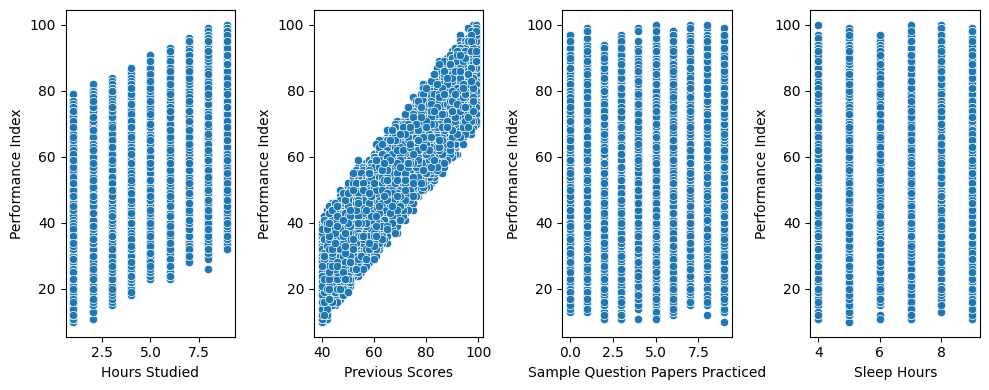

In [31]:
fig,axes=plt.subplots(ncols=4,figsize=(10,4))
sns.scatterplot(num_df,x='Hours Studied',y='Performance Index',ax=axes[0])
sns.scatterplot(num_df,x='Previous Scores',y='Performance Index',ax=axes[1])
sns.scatterplot(num_df,x='Sample Question Papers Practiced',y='Performance Index',ax=axes[2])
sns.scatterplot(num_df,x='Sleep Hours',y='Performance Index',ax=axes[3])
plt.tight_layout()
plt.show()

In [32]:
# model.score(x,y)
model.score(xtest,ytest)      #var(Y)--ytest


0.9887144552384186

In [33]:
#we use MSE during model wvaluation and cost function.(Average of how bad is model performing)

In [34]:
num_df.corr()['Performance Index']#previous score having strong relationship.

Hours Studied                       0.373730
Previous Scores                     0.915189
Sleep Hours                         0.048106
Sample Question Papers Practiced    0.043268
Performance Index                   1.000000
Name: Performance Index, dtype: float64

In [35]:
from sklearn.metrics import r2_score,mean_squared_error,root_mean_squared_error   #it contains all the model evaluation method

In [36]:
#r2_score
y_pred=model.predict(xtest)

In [37]:
r2_score(ytest,predicted_values)

0.9887144552384186

In [38]:
mean_squared_error(ytest,y_pred)

4.182254914593818

In [39]:
rmse=root_mean_squared_error(ytest,y_pred)   #important for interview
#np.sqrt(mee)
rmse

2.0450562130645253

In [40]:
target_mean=ytest.mean()
target_mean

np.float64(54.878)

In [41]:
MSE_Evaluation=rmse/target_mean
MSE_Evaluation

np.float64(0.03726550189628859)

In [42]:
model.score(xtrain,ytrain)   #model performance is good and trained properly,and predicted crrct value on trained data

0.9884388348325367

In [43]:
predicted=model.predict(xtrain)

In [44]:
r2_score(ytrain,predicted)

0.9884388348325367

In [45]:
model.score(xtest,ytest)  #model gives the crrct values on test data and performance is good

0.9887144552384186

In [46]:
pred=model.predict(xtest)

In [47]:
r2_score(ytrain,predicted)

0.9884388348325367

Decision Tree regressior